<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M_11_A_12__ANN_Neural_Network_Deep_Learning_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 12: Neural Network and Deep Learning Basics
#Name Ayleen Santander

#Part 1: Dataset Preparation
- Data Selected : Fashion MNIST: https://github.com/zalandoresearch/fashion-mnist: 70,000 images in 10 fashion categories.

- Basic Information:
I pulled the four raw files straight from the Zalando repo and wrote a loader to go with them. Verified: 60,000 train + 10,000 test = 70,000 images, 28×28 grayscale, pixels 0–255, perfectly balanced at 6,000 per class in train and 1,000 per class in test.

- Labels map like this: 0 T-shirt/top, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat, 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot.

In [1]:
#Data Loading and Visualization/ Load the dataset using TensorFlow/Keras.
#Visualize sample images from each class to understand the variety within the datasets.
#Import Libraries
import pandas as pd
import numpy as np
import gzip, os, urllib.request
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras import layers, Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score)
import time
from tensorflow.keras import layers, Sequential

In [2]:
#Check tf version
tf.__version__

'2.20.0'

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
#load dataset
BASE = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion"
FILES = {
    "X_train": "train-images-idx3-ubyte.gz",
    "y_train": "train-labels-idx1-ubyte.gz",
    "X_test":  "t10k-images-idx3-ubyte.gz",
    "y_test":  "t10k-labels-idx1-ubyte.gz",
}
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
def read_idx(path):
    with gzip.open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), "big")
        n_dims = magic & 0xFF
        dims = [int.from_bytes(f.read(4), "big") for _ in range(n_dims)]
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)

def load_fashion_mnist(data_dir="fashion_mnist_data"):
    os.makedirs(data_dir, exist_ok=True)
    out = {}
    for key, fname in FILES.items():
        dest = os.path.join(data_dir, fname)
        if not os.path.exists(dest):
            print(f"Downloading {fname} ...")
            urllib.request.urlretrieve(f"{BASE}/{fname}", dest)
        out[key] = read_idx(dest)
    return out["X_train"], out["y_train"], out["X_test"], out["y_test"]

X_train, y_train, X_test, y_test = load_fashion_mnist()
print(X_train.shape, X_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [5]:
#Ready for scikit-learn
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
X_test_flat  = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

0  T-shirt/top  6000
1  Trouser      6000
2  Pullover     6000
3  Dress        6000
4  Coat         6000
5  Sandal       6000
6  Shirt        6000
7  Sneaker      6000
8  Bag          6000
9  Ankle boot   6000


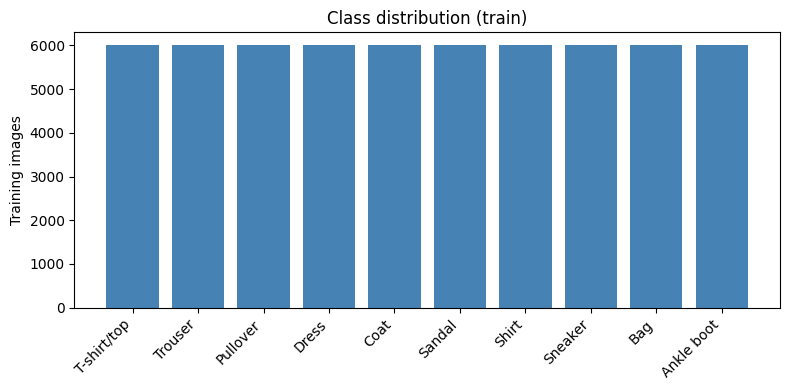

In [6]:
#Visualize the dataset
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

counts = np.bincount(y_train)
for i, c in enumerate(counts):
    print(f"{i}  {CLASS_NAMES[i]:<12} {c}")

plt.figure(figsize=(8, 4))
plt.bar(CLASS_NAMES, counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Training images")
plt.title("Class distribution (train)")
plt.tight_layout()
plt.show()

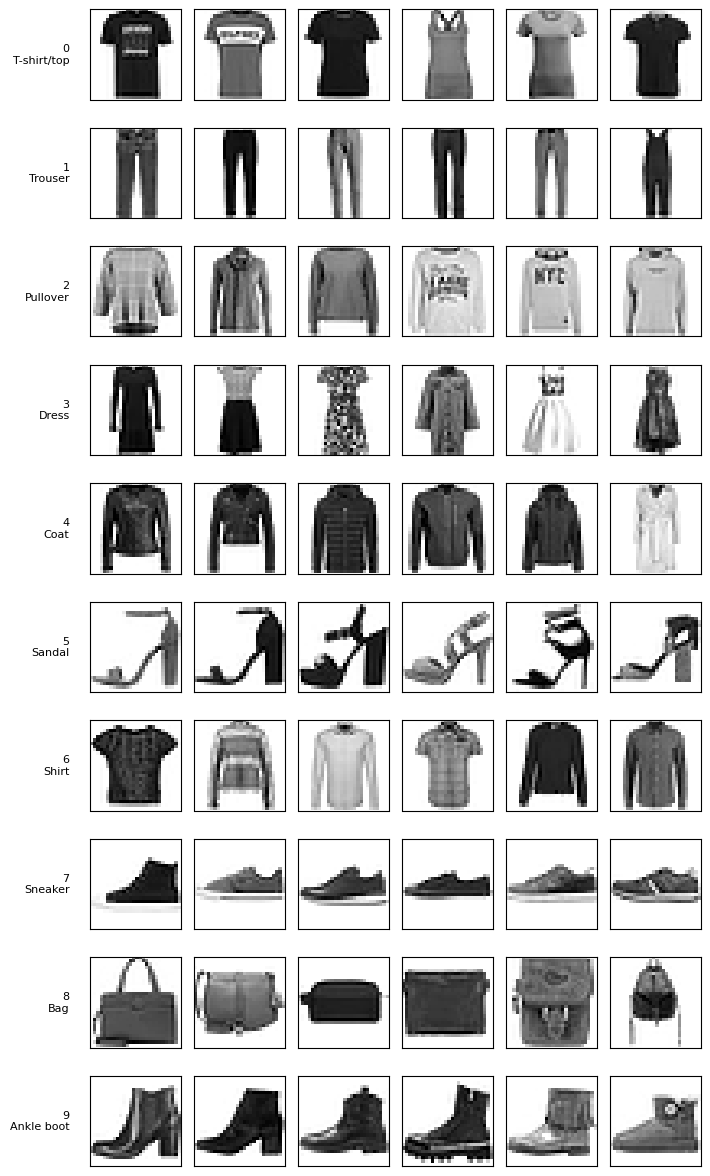

In [7]:
#Look at the images
N = 6
rng = np.random.default_rng(42)
fig, axes = plt.subplots(10, N, figsize=(N * 1.2, 12))

for row in range(10):
    idx = rng.choice(np.where(y_train == row)[0], N, replace=False)
    for col in range(N):
        ax = axes[row, col]
        ax.imshow(X_train[idx[col]], cmap="gray_r")
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"{row}\n{CLASS_NAMES[row]}", rotation=0, ha="right", va="center", fontsize=8, labelpad=15)
plt.tight_layout()
plt.show()

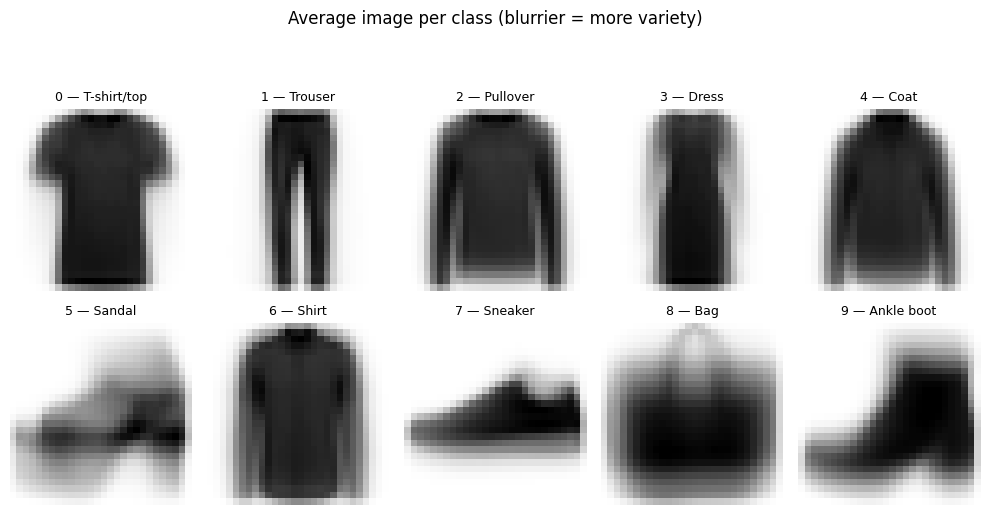

In [8]:
#Blurry results high variation in shape and pose
fig, axes = plt.subplots(2, 5, figsize=(10, 5.5))

for cls, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[y_train == cls].mean(axis=0), cmap="gray_r")
    ax.set_title(f"{cls} — {CLASS_NAMES[cls]}", fontsize=9)
    ax.axis("off")

fig.suptitle("Average image per class (blurrier = more variety)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Note: Trouser, Bag, and Sandal come out sharp and distinct, so a model will pick them up easily. T-shirt, Pullover, Coat, and Shirt all average into nearly the same torso silhouette, which is exactly why those four classes get confused later.

#Pat 2: Image Preprocessing

In [9]:
##Normalization:
#Scale the image pixel values to a range of 0 to 1 to facilitate neural network training.
#Normalize pixel values from 0-255 to 0-1
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm  = X_test.astype("float32") / 255.0

print("dtype :", X_train_norm.dtype)
print("range :", X_train_norm.min(), "-", X_train_norm.max())
print("shape :", X_train_norm.shape, X_test_norm.shape)

dtype : float32
range : 0.0 - 1.0
shape : (60000, 28, 28) (10000, 28, 28)


In [10]:
#Keras CNN, channel dimension
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_norm.reshape(-1, 28, 28, 1)
print(X_train_cnn.shape)

(60000, 28, 28, 1)


In [11]:
#Preprocess
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
X_test_flat  = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

print(X_train_flat.shape, X_test_flat.shape)
print("range:", X_train_flat.min(), "-", X_train_flat.max())

(60000, 784) (10000, 784)
range: 0.0 - 1.0


In [12]:
#Baseline model
# 10k subset keeps this to ~1-2 min instead of ~15
rng = np.random.default_rng(42)
sub = rng.choice(len(X_train_flat), 10000, replace=False)

pipe = Pipeline([("scaler", StandardScaler()),("clf", LogisticRegression(max_iter=1000, n_jobs=-1)),])

pipe.fit(X_train_flat[sub], y_train[sub])
print("Train accuracy:", pipe.score(X_train_flat[sub], y_train[sub]))
print("Test accuracy :", pipe.score(X_test_flat, y_test))

Train accuracy: 0.9662
Test accuracy : 0.7995


              precision    recall  f1-score   support

 T-shirt/top       0.74      0.74      0.74      1000
     Trouser       0.96      0.94      0.95      1000
    Pullover       0.65      0.69      0.67      1000
       Dress       0.80      0.79      0.79      1000
        Coat       0.67      0.71      0.69      1000
      Sandal       0.92      0.89      0.90      1000
       Shirt       0.55      0.51      0.53      1000
     Sneaker       0.88      0.90      0.89      1000
         Bag       0.92      0.89      0.90      1000
  Ankle boot       0.91      0.94      0.92      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000

------------------------------------------------------------------------------------------


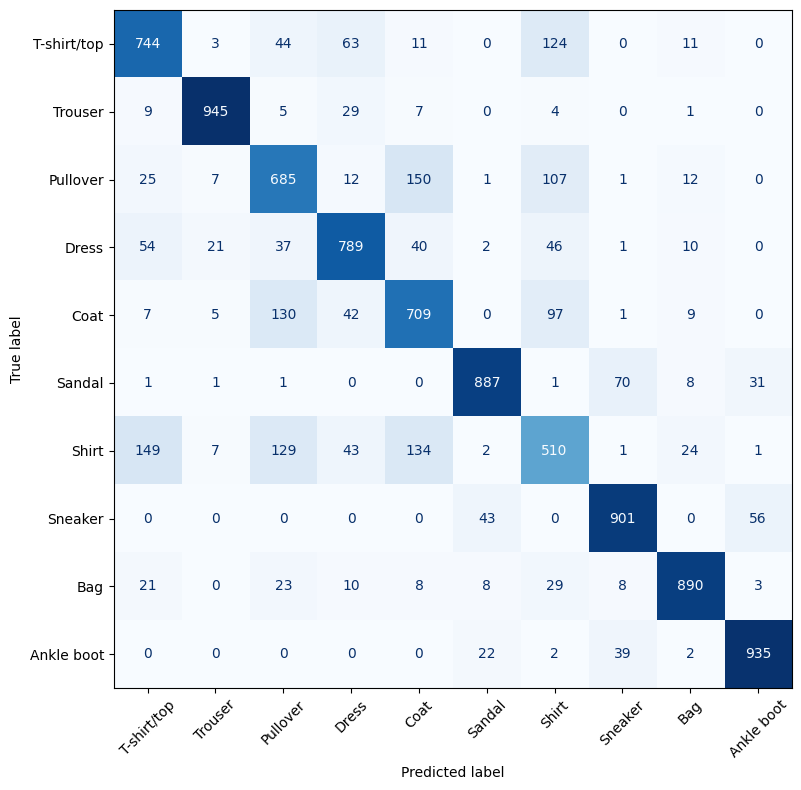

In [13]:
#Check where it fails
y_pred = pipe.predict(X_test_flat)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
print('--'*45)

#Visual of where it fails
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES, xticks_rotation=45, cmap="Blues", colorbar=False, ax=ax)
plt.tight_layout(); plt.show()

Note:

#Data Augmentation (optional):
#To improve model robustness, optionally augment the training
#data using transformations like rotation, translation, scaling, and horizontal flipping using ImageDataGenerator in Keras.

In [14]:
#ImageDataGenerator needs a channel dimmension:previous code
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_norm.reshape(-1, 28, 28, 1)

datagen = ImageDataGenerator(
    rotation_range=10,        # degrees
    width_shift_range=0.1,    # fraction of width
    height_shift_range=0.1,
    zoom_range=0.1,           # scaling
    horizontal_flip=True,
    fill_mode="nearest",      # how to fill pixels exposed by a shift
)

datagen.fit(X_train_cnn)

train_gen = datagen.flow(X_train_cnn, y_train, batch_size=64, seed=42)
print("batches per epoch:", len(train_gen))

batches per epoch: 938


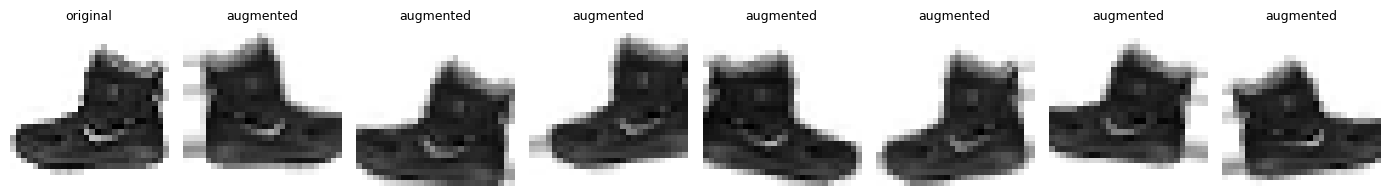

In [15]:
#Check what the transformations actually do before train them:
sample = X_train_cnn[:1]                      # one image
aug = datagen.flow(sample, batch_size=1, seed=42)

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
axes[0].imshow(sample[0].squeeze(), cmap="gray_r")
axes[0].set_title("original", fontsize=9); axes[0].axis("off")

for ax in axes[1:]:
    ax.imshow(next(aug)[0].squeeze(), cmap="gray_r")
    ax.set_title("augmented", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [16]:
#Definitions of CNN
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),   # 10 classes
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [17]:
#Fit with the generator instead of raw arrays
history = model.fit(train_gen, epochs=5, validation_data=(X_test_cnn, y_test),)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.7494 - loss: 0.6760 - val_accuracy: 0.8428 - val_loss: 0.4477
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8122 - loss: 0.5070 - val_accuracy: 0.8608 - val_loss: 0.3953
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8335 - loss: 0.4454 - val_accuracy: 0.8618 - val_loss: 0.3747
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8456 - loss: 0.4173 - val_accuracy: 0.8607 - val_loss: 0.3757
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8554 - loss: 0.3949 - val_accuracy: 0.8811 - val_loss: 0.3335


In [18]:
augment = Sequential([
    layers.RandomRotation(0.03),      # fraction of 2π ≈ 10°
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
])

#Part 3: Neural Network Implementation:
- Model Architecture:
1. Construct a simple feedforward neural network with at least one hidden layer.
2. Use ReLU activation functions for the hidden layers and a Softmax output layer.

In [19]:
#Model Architecture:Construct a simple feedforward neural network with at least one hidden layer.
model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                          # 28x28 -> 784

    layers.Dense(128, activation="relu"),      # hidden layer
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),       # second hidden layer
    layers.Dropout(0.2),

    layers.Dense(10, activation="softmax"),    # 10 classes
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Note: Different architecture than the CNN — a feedforward net takes a flat vector, so the 28×28 image gets unrolled into 784 inputs first.

In [20]:
#Train it on the normalized arrays:
history = model.fit(X_train_norm, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1,)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7804 - loss: 0.6170 - val_accuracy: 0.8452 - val_loss: 0.4121
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8439 - loss: 0.4356 - val_accuracy: 0.8518 - val_loss: 0.4033
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8572 - loss: 0.3951 - val_accuracy: 0.8657 - val_loss: 0.3629
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8666 - loss: 0.3711 - val_accuracy: 0.8702 - val_loss: 0.3626
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8705 - loss: 0.3554 - val_accuracy: 0.8717 - val_loss: 0.3418


In [21]:
#Architecture verification
for layer in model.layers:
    act = getattr(layer, "activation", None)
    print(f"{layer.name:<12} {act.__name__ if act else '—'}")

flatten_1    —
dense_2      relu
dropout_1    —
dense_3      relu
dropout_2    —
dense_4      softmax


In [22]:
#Compilation: Compile the model with the Adam optimizer, categorical crossentropy as the loss function, and accuracy as the metric.
#labels are 0-9
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"],)

Note: sparse_categorical_crossentropy is categorical crossentropy — same math, it just takes integer labels directly instead of requiring one-hot vectors.

In [23]:
#Categorical crossentropy as the loss function
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"],
)

In [24]:
#Then train with encoded labes, not the originals
history = model.fit(X_train_norm, y_train_cat, epochs=5, batch_size=64, validation_split=0.1,)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8743 - loss: 0.3427 - val_accuracy: 0.8775 - val_loss: 0.3448
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8791 - loss: 0.3301 - val_accuracy: 0.8760 - val_loss: 0.3328
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8819 - loss: 0.3201 - val_accuracy: 0.8743 - val_loss: 0.3291
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8844 - loss: 0.3126 - val_accuracy: 0.8768 - val_loss: 0.3332
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8880 - loss: 0.3022 - val_accuracy: 0.8840 - val_loss: 0.3137


In [25]:
#Training:  Train the model on the training set using batch sizes of 32 or 64 for 10 to 20 epochs.
history = model.fit(X_train_norm, y_train_cat,     # y_train if you kept sparse
    epochs=15, batch_size=64, validation_split=0.1, verbose=1,)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8901 - loss: 0.2980 - val_accuracy: 0.8818 - val_loss: 0.3325
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8905 - loss: 0.2939 - val_accuracy: 0.8867 - val_loss: 0.3190
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8928 - loss: 0.2859 - val_accuracy: 0.8847 - val_loss: 0.3108
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8959 - loss: 0.2815 - val_accuracy: 0.8835 - val_loss: 0.3179
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8968 - loss: 0.2772 - val_accuracy: 0.8870 - val_loss: 0.3112
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8993 - loss: 0.2704 - val_accuracy: 0.8840 - val_loss: 0.3125
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8993 - loss: 0.2697 - val_accuracy: 0.8807 - val_loss: 0.3355
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9016 - loss: 0.2640 - val_accuracy: 0.

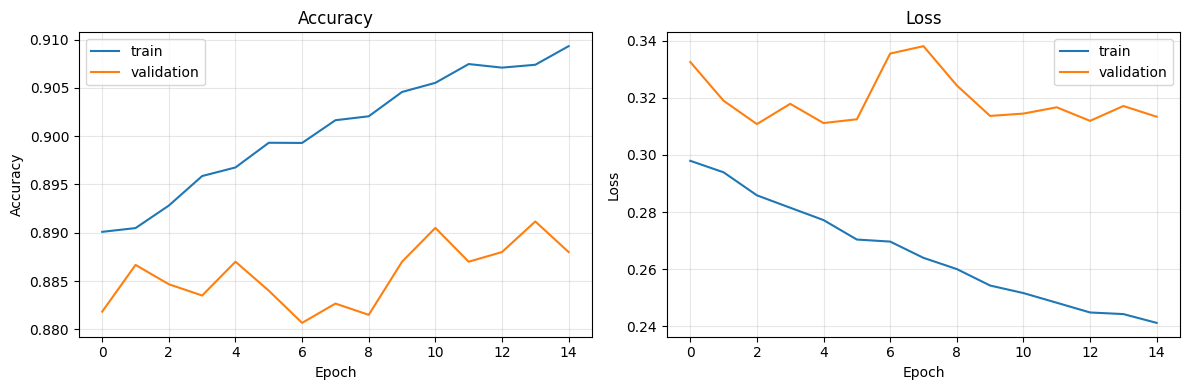

In [26]:
#Check the loss and accuracy curves:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="validation")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="validation")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

#Part 4: Model Evaluation

In [27]:
#Performance Metrics: 1. Assess the model using accuracy, precision, recall, and F1-score on the test set.
#2. Present a confusion matrix and classification report to evaluate performance across all categories.
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Predictions -> integer labels
y_prob = model.predict(X_test_norm, verbose=0)      # output probabilities
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)              # use y_test if you kept sparse

print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(precision_score(y_true, y_pred, average="macro"), 4))
print("Recall   :", round(recall_score(y_true, y_pred, average="macro"), 4))
print("F1-score :", round(f1_score(y_true, y_pred, average="macro"), 4))

Accuracy : 0.8865
Precision: 0.8878
Recall   : 0.8865
F1-score : 0.8866


In [28]:
#Classification report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

 T-shirt/top     0.8596    0.8020    0.8298      1000
     Trouser     0.9908    0.9690    0.9798      1000
    Pullover     0.8471    0.7590    0.8006      1000
       Dress     0.8553    0.9100    0.8818      1000
        Coat     0.7796    0.8490    0.8128      1000
      Sandal     0.9699    0.9680    0.9690      1000
       Shirt     0.7025    0.7250    0.7136      1000
     Sneaker     0.9527    0.9460    0.9493      1000
         Bag     0.9692    0.9740    0.9716      1000
  Ankle boot     0.9516    0.9630    0.9573      1000

    accuracy                         0.8865     10000
   macro avg     0.8878    0.8865    0.8866     10000
weighted avg     0.8878    0.8865    0.8866     10000



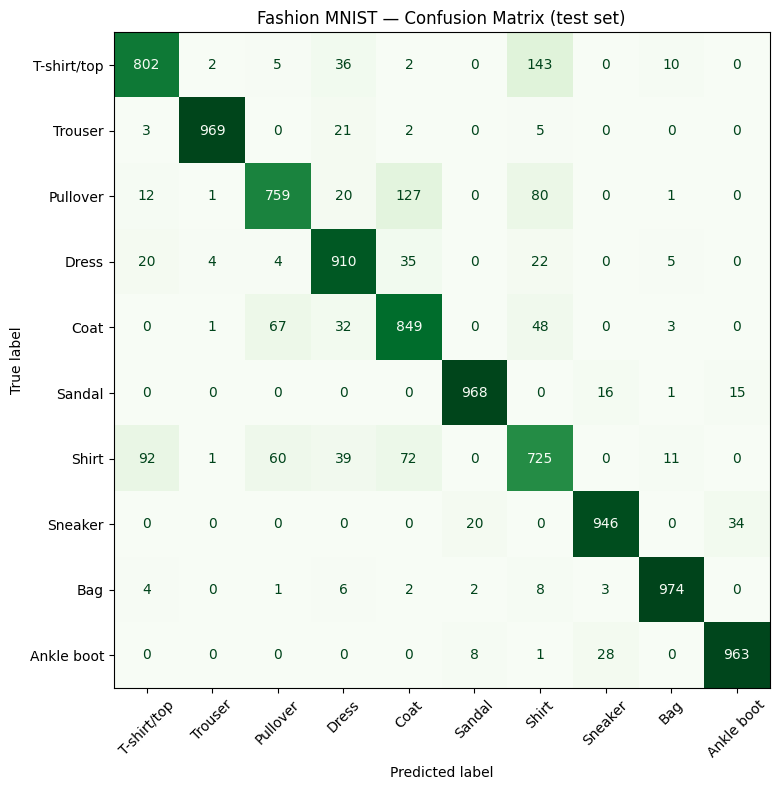

In [29]:
#Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=CLASS_NAMES, xticks_rotation=45, cmap="Greens", colorbar=False, ax=ax,
)
ax.set_title("Fashion MNIST — Confusion Matrix (test set)")
plt.tight_layout(); plt.show()

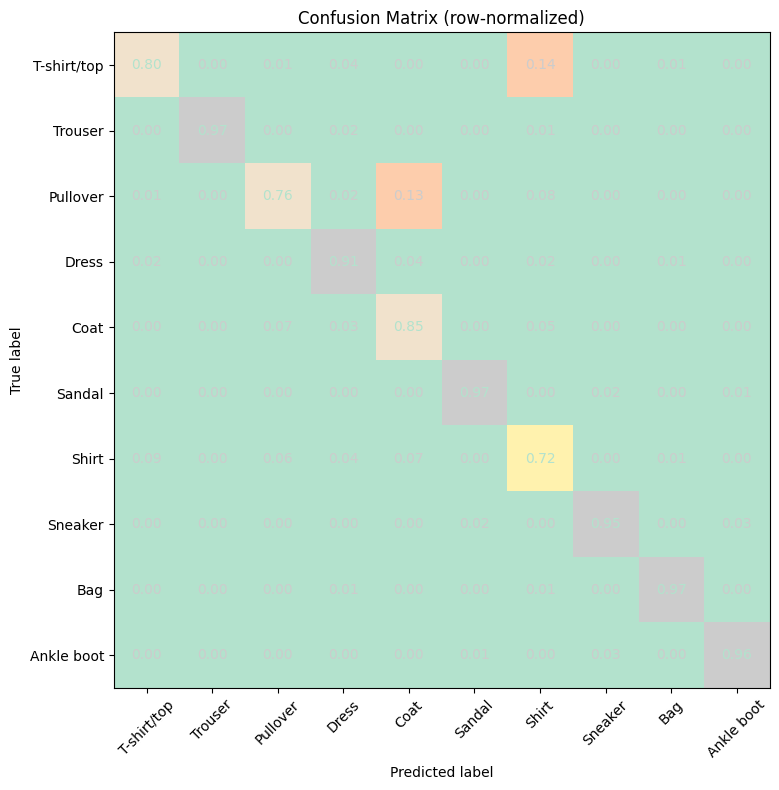

In [30]:
#Normalize easier to read
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=CLASS_NAMES, xticks_rotation=45, cmap="Pastel2", colorbar=False,
    normalize="true", values_format=".2f", ax=ax,)
ax.set_title("Confusion Matrix (row-normalized)")
plt.tight_layout(); plt.show()

In [31]:
#Model Improvements: 1. Experiment with different numbers of layers, layer sizes, and optimizers to improve accuracy.
#2. Evaluate the impact of data augmentation on model performance.
#Experimet 1: architecture and optimizer
def build_mlp(hidden_sizes, optimizer="adam", dropout=0.2):
    net = [layers.Input(shape=(28, 28)), layers.Flatten()]
    for units in hidden_sizes:
        net.append(layers.Dense(units, activation="relu"))
        if dropout:
            net.append(layers.Dropout(dropout))
    net.append(layers.Dense(10, activation="softmax"))

    m = models.Sequential(net)
    m.compile(optimizer=optimizer,
              loss="categorical_crossentropy",
              metrics=["accuracy"])
    return m


configs = [
    ("1 layer  [128]",        [128],           "adam"),
    ("2 layers [128,64]",     [128, 64],       "adam"),
    ("3 layers [256,128,64]", [256, 128, 64],  "adam"),
    ("2 layers [512,256]",    [512, 256],      "adam"),
    ("2 layers [128,64]",     [128, 64],       "sgd"),
    ("2 layers [128,64]",     [128, 64],       "rmsprop"),
]

results = []
for name, sizes, opt in configs:
    t0 = time.time()
    m = build_mlp(sizes, optimizer=opt)
    h = m.fit(X_train_norm, y_train_cat, epochs=15, batch_size=64,
              validation_split=0.1, verbose=0)
    test_loss, test_acc = m.evaluate(X_test_norm, y_test_cat, verbose=0)

    results.append({
        "architecture": name,
        "optimizer": opt,
        "params": m.count_params(),
        "val_acc": round(max(h.history["val_accuracy"]), 4),
        "test_acc": round(test_acc, 4),
        "minutes": round((time.time() - t0) / 60, 1),
    })
    print(f"done: {name} / {opt}  ->  test {test_acc:.4f}")

df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
df

done: 1 layer  [128] / adam  ->  test 0.8784
done: 2 layers [128,64] / adam  ->  test 0.8820
done: 3 layers [256,128,64] / adam  ->  test 0.8834
done: 2 layers [512,256] / adam  ->  test 0.8924
done: 2 layers [128,64] / sgd  ->  test 0.8556
done: 2 layers [128,64] / rmsprop  ->  test 0.8737


,architecture,optimizer,params,val_acc,test_acc,minutes
3,"2 layers [512,256]",adam,535818,0.8967,0.8924,0.7
2,"3 layers [256,128,64]",adam,242762,0.8877,0.8834,0.7
1,"2 layers [128,64]",adam,109386,0.8872,0.8820,0.7
0,1 layer [128],adam,101770,0.8902,0.8784,0.7
5,"2 layers [128,64]",rmsprop,109386,0.8878,0.8737,0.7
4,"2 layers [128,64]",sgd,109386,0.8590,0.8556,0.7


In [32]:
#Experiment 2: augmentation impact
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_norm.reshape(-1, 28, 28, 1)

def build_cnn():
    m = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="categorical_crossentropy",
              metrics=["accuracy"])
    return m

In [33]:
# Same split for both runs so the comparison is clean
split = int(len(X_train_cnn) * 0.9)
Xtr, Xval = X_train_cnn[:split], X_train_cnn[split:]
ytr, yval = y_train_cat[:split], y_train_cat[split:]

In [34]:
# (a) baseline, no augmentation
cnn_plain = build_cnn()
cnn_plain.fit(Xtr, ytr, epochs=5, batch_size=64, validation_data=(Xval, yval), verbose=0)
_, acc_plain = cnn_plain.evaluate(X_test_cnn, y_test_cat, verbose=0)

In [36]:
# (b) with augmentation
datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode="nearest")
cnn_aug = build_cnn()
cnn_aug.fit(datagen.flow(Xtr, ytr, batch_size=64, seed=42), epochs=5, validation_data=(Xval, yval), verbose=0)
_, acc_aug = cnn_aug.evaluate(X_test_cnn, y_test_cat, verbose=0)

print(f"CNN without augmentation: {acc_plain:.4f}")
print(f"CNN with augmentation   : {acc_aug:.4f}")
print(f"Difference              : {acc_aug - acc_plain:+.4f}")

CNN without augmentation: 0.9109
CNN with augmentation   : 0.8862
Difference              : -0.0247


Note: Augmentation needs a CNN to be a fair test. Flattening throws away the spatial structure the transformations preserve, so on a Dense net it usually makes things slightly worse, which is itself a finding you can report.

In [37]:
#Making the predictions and evaluating the model/Predicting the result of a single observation
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

i = 0                                  # index of the image to predict
single = X_test_norm[i]                # shape (28, 28)

# Keras expects a batch, so add the batch dimension
single_batch = np.expand_dims(single, axis=0)     # shape (1, 28, 28)

probs = model.predict(single_batch, verbose=0)[0] # shape (10,)
pred  = np.argmax(probs)
true  = np.argmax(y_test_cat[i])                  # y_test[i] if you kept sparse

print(f"Predicted : {pred} - {CLASS_NAMES[pred]}")
print(f"Actual    : {true} - {CLASS_NAMES[true]}")
print(f"Confidence: {probs[pred]:.2%}")
print("Correct" if pred == true else "Incorrect")

Predicted : 9 - Ankle boot
Actual    : 9 - Ankle boot
Confidence: 99.97%
Correct


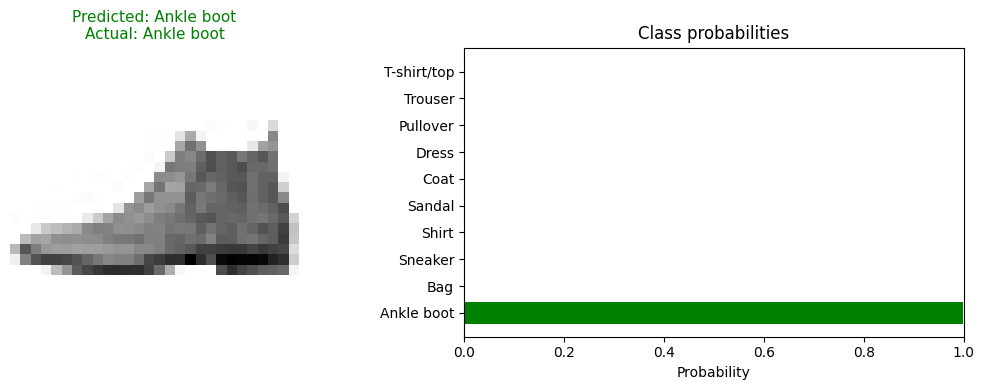

In [38]:
#Show the image alongside the full probability breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.imshow(single, cmap="gray_r")
ax1.set_title(f"Predicted: {CLASS_NAMES[pred]}\nActual: {CLASS_NAMES[true]}",
              fontsize=11, color=("green" if pred == true else "red"))
ax1.axis("off")

colors = ["green" if j == true else "steelblue" for j in range(10)]
ax2.barh(CLASS_NAMES, probs, color=colors)
ax2.set_xlim(0, 1)
ax2.set_xlabel("Probability")
ax2.set_title("Class probabilities")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

#Part 5: Application Demonstration:
1. Practical Deployment Scenario:
- Discuss a hypothetical application of the trained model in a real-world scenario (e.g., digital media organization, fashion retail, or automated surveillance).
- Address potential operational issues like model scalability, real-time processing needs, and integration with existing technology.

The scenario

A marketplace like Poshmark or Depop where individual sellers upload their own listings. Sellers are lazy about categorization, they skip the dropdown, pick "Other," or mislabel a pullover as a coat. Bad categories mean the item never surfaces in filtered searches, so it doesn't sell, so the seller leaves the platform.

The model runs at upload time: seller photographs the item, the classifier predicts the category, and the app pre-fills the dropdown with the seller confirming or correcting. That framing matters for the write-up, it's assistive, not autonomous. A wrong prediction costs one tap, not a lost sale. That's what makes an 89% model deployable when a fully automated version at the same accuracy wouldn't be.

Operational issues

Real-time processing. A forward pass through this network is a handful of matrix multiplications, single-digit milliseconds on CPU. Inference is nowhere near the bottleneck. The actual latency sits in image upload over mobile data and the preprocessing step: resize, grayscale, center, normalize. Budget most of your time there. The practical target is a prediction back before the seller finishes typing the item description, so it feels like autofill rather than a loading state.

Scalability. The model is small enough that a single CPU instance handles a large volume of concurrent uploads. Uploads are also bursty and predictable, evenings and weekends, so autoscaling on request queue depth costs far less than provisioning for peak. If mobile latency becomes the problem, the model is small enough to convert to TensorFlow Lite and run on-device, which eliminates the round trip entirely and works offline.

Integration. This is the part most write-ups skip and it's where deployments actually fail. The classifier is one service behind an API endpoint, but it has to fit the existing stack: the platform's category taxonomy almost certainly isn't your 10 classes, so you need an explicit mapping layer and a decision about what happens to items that fall outside it. You also need the confidence score surfaced, not just the label, below some threshold, show the top three options instead of one guess. And you need prediction logging with the seller's final choice, because the corrections are free labeled training data for the next model version.

Monitoring and drift. Sellers photograph items on beds, carpets, and hangers in bad lighting. Your model learned from clean centered studio images on white backgrounds. That gap is the single biggest risk in this deployment, and it will show up as accuracy that's much worse in production than on your test set. Fashion also changes, new silhouettes appear, and a category distribution from last year drifts. Track the seller-correction rate per category as your live metric, and retrain when it climbs.

Known weakness. Your confusion matrix already tells you where this breaks: Shirt, T-shirt, Pullover, and Coat blur together. Those are also high-volume categories on a real marketplace, so the errors concentrate exactly where they hurt. Options are to merge them into a single "Tops" bucket with a follow-up question, raise the confidence threshold for just those four, or accept it and rely on the seller confirmation step. Naming the tradeoff explicitly is stronger than pretending the model is uniformly good.

